# High-protein agent eval report

Loads the latest (or a specified) `high_protein_20_*` suite under `scratch/recipe_opt_runs/eval_suites/`.

**Modes**
- `neighborhood` — canonical start
- `creative` — creative / OOD with neighborhood catalog
- `creative_example` — creative, with a neighborhood example recipe shown to the draft LLM

**Targets:** neighborhood mean PFC +10pp protein / −5pp carbs / −5pp fat, then ±2% box.

**Metrics:** ratio loss, nutrient loss, LLM holistic score (0–10).

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "scripts").is_dir():
    ROOT = ROOT.parent

SUITE_ROOT = ROOT / "scratch" / "recipe_opt_runs" / "eval_suites"
# Set to a specific suite dir to pin, else latest high_protein_* suite is used.
SUITE_DIR: Path | None = None

def find_suite() -> Path:
    if SUITE_DIR is not None:
        return Path(SUITE_DIR)
    cands = sorted(
        SUITE_ROOT.glob("high_protein_*"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not cands:
        raise FileNotFoundError(f"No high_protein_* suites under {SUITE_ROOT}")
    return cands[0]

suite_dir = find_suite()
summary_path = suite_dir / "high_protein_eval_summary.json"
metrics_path = suite_dir / "high_protein_metrics.jsonl"
print("Suite:", suite_dir)
print("summary exists:", summary_path.exists(), "· metrics exists:", metrics_path.exists())

Suite: /Users/danielcosta/Berkeley/Capstone/scratch/recipe_opt_runs/eval_suites/high_protein_20_20260719T200634Z
summary exists: True · metrics exists: True


In [2]:
if metrics_path.exists():
    rows = [json.loads(line) for line in metrics_path.read_text().splitlines() if line.strip()]
elif summary_path.exists():
    rows = (json.loads(summary_path.read_text())).get("rows") or []
else:
    raise FileNotFoundError("Eval not finished yet — no metrics/summary file.")

df = pd.DataFrame(rows)
ok = df[df["error"].isna() | (df["error"].astype(str) == "None") | (df["error"] == "")].copy() if "error" in df.columns else df.copy()
if "error" in df.columns:
    ok = df[df["error"].isnull() | (df["error"].astype(str).isin(["None", "", "nan"]))].copy()
print(f"Rows: {len(df)} total · {len(ok)} successful")
display(ok.groupby("mode").size().rename("n_ok"))

Rows: 60 total · 55 successful


mode
creative            17
creative_example    18
neighborhood        20
Name: n_ok, dtype: int64

## Means by mode

In [3]:
METRICS = ["ratio_loss", "nutrient_loss", "holistic_0_10"]

def mean_table(frame: pd.DataFrame) -> pd.DataFrame:
    out = []
    for mode, g in frame.groupby("mode"):
        row = {"mode": mode, "n": len(g)}
        for m in METRICS:
            vals = pd.to_numeric(g[m], errors="coerce").dropna()
            row[f"mean_{m}"] = float(vals.mean()) if len(vals) else np.nan
            row[f"n_{m}"] = int(len(vals))
        out.append(row)
    return pd.DataFrame(out).set_index("mode")

means = mean_table(ok)
display(means)

if summary_path.exists():
    summary = json.loads(summary_path.read_text())
    print("Suite by_mode (from runner):")
    print(json.dumps(summary.get("by_mode") or {}, indent=2))

,n,mean_ratio_loss,n_ratio_loss,mean_nutrient_loss,n_nutrient_loss,mean_holistic_0_10,n_holistic_0_10
mode,,,,,,,
creative,17,0.013816,17,0.048943,17,4.000000,17
creative_example,18,0.013458,18,0.035037,18,5.555556,18
neighborhood,20,0.096950,20,0.001661,20,5.800000,20


Suite by_mode (from runner):
{
  "neighborhood": {
    "n_ok": 20,
    "n_total": 20,
    "mean_ratio_loss": 0.09694977453749724,
    "mean_nutrient_loss": 0.0016606003190606621,
    "mean_holistic_0_10": 5.8
  },
  "creative": {
    "n_ok": 17,
    "n_total": 20,
    "mean_ratio_loss": 0.013815985383244607,
    "mean_nutrient_loss": 0.04894303317390397,
    "mean_holistic_0_10": 4.0
  },
  "creative_example": {
    "n_ok": 18,
    "n_total": 20,
    "mean_ratio_loss": 0.01345765817288965,
    "mean_nutrient_loss": 0.03503650820723473,
    "mean_holistic_0_10": 5.555555555555555
  }
}


## Histograms by mode

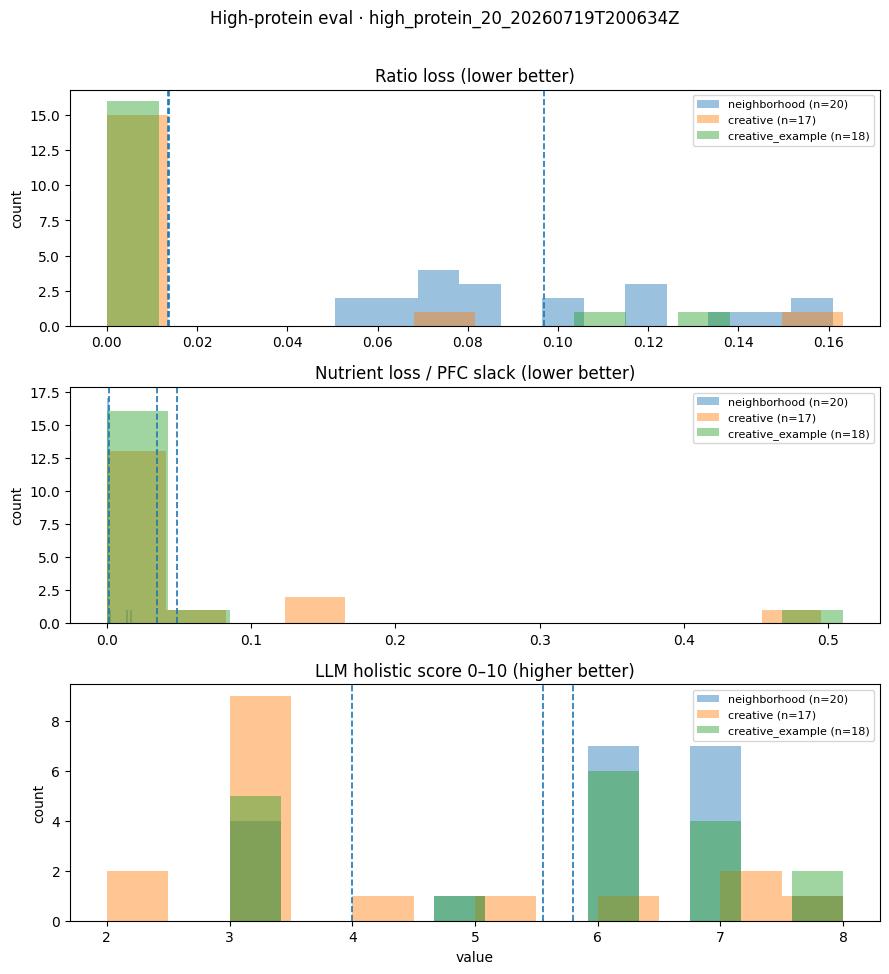

In [4]:
modes = [m for m in ["neighborhood", "creative", "creative_example"] if m in set(ok["mode"].dropna())]
titles = {
    "ratio_loss": "Ratio loss (lower better)",
    "nutrient_loss": "Nutrient loss / PFC slack (lower better)",
    "holistic_0_10": "LLM holistic score 0–10 (higher better)",
}

fig, axes = plt.subplots(len(METRICS), 1, figsize=(9, 3.2 * len(METRICS)), sharex=False)
if len(METRICS) == 1:
    axes = [axes]

for ax, metric in zip(axes, METRICS):
    for mode in modes:
        vals = pd.to_numeric(ok.loc[ok["mode"] == mode, metric], errors="coerce").dropna().values
        if len(vals) == 0:
            continue
        ax.hist(vals, bins=min(12, max(5, len(vals))), alpha=0.45, label=f"{mode} (n={len(vals)})")
        ax.axvline(float(np.mean(vals)), linestyle="--", linewidth=1.2)
    ax.set_title(titles[metric])
    ax.set_ylabel("count")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("value")
fig.suptitle(f"High-protein eval · {suite_dir.name}", y=1.01)
fig.tight_layout()
plt.show()

## Per-mode mean bar chart

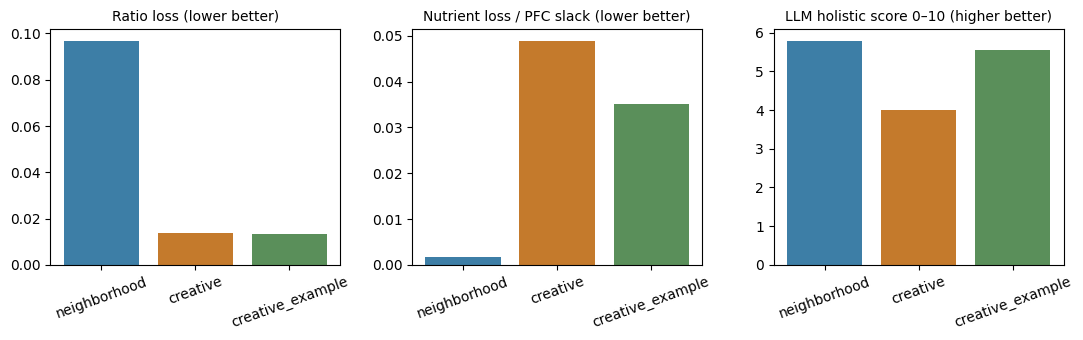

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, metric in zip(axes, METRICS):
    ys = []
    labels = []
    for mode in modes:
        vals = pd.to_numeric(ok.loc[ok["mode"] == mode, metric], errors="coerce").dropna()
        if len(vals) == 0:
            continue
        labels.append(mode)
        ys.append(float(vals.mean()))
    ax.bar(labels, ys, color=["#3d7ea6", "#c47a2c", "#5a8f5a"][: len(labels)])
    ax.set_title(titles[metric], fontsize=10)
    ax.tick_params(axis="x", labelrotation=20)
fig.tight_layout()
plt.show()

## Paired dish comparison (same canonical across modes)

In [6]:
pivot = ok.pivot_table(index=["canonical_id", "title"], columns="mode", values=METRICS, aggfunc="first")
display(pivot.head(20))

# Win counts: lower better for losses, higher better for holistic
if set(modes) >= {"neighborhood", "creative", "creative_example"}:
    wins = {m: {"ratio_loss": 0, "nutrient_loss": 0, "holistic_0_10": 0} for m in modes}
    for _, row in ok.groupby("canonical_id"):
        by = {r["mode"]: r for _, r in row.iterrows()}
        if len(by) < 2:
            continue
        for metric, higher_better in [("ratio_loss", False), ("nutrient_loss", False), ("holistic_0_10", True)]:
            scored = {m: by[m].get(metric) for m in modes if m in by and by[m].get(metric) is not None}
            if len(scored) < 2:
                continue
            best = max(scored, key=scored.get) if higher_better else min(scored, key=scored.get)
            wins[best][metric] += 1
    display(pd.DataFrame(wins).T.rename_axis("mode"))

holistic_0_10                                \
mode                                   creative creative_example neighborhood   
canonical_id title                                                              
10           Al Pastor                      3.0              NaN          7.0   
23           Arroz con Pollo                3.0              NaN          3.0   
30           Avgolemono Soup                7.0              6.0          7.0   
35           BBQ Ribs                       2.0              6.0          7.0   
36           Baba Ganoush                   NaN              3.0          7.0   
48           Barbacoa                       3.0              7.0          3.0   
51           Beef Bourguignon               3.0              6.0          6.0   
52           Beef Enchiladas                NaN              7.0          6.0   
61           Biryani                        3.0              3.0          6.0   
67           Bobotie                        2.0              6.0          7.0   
79           Buffalo Wings                  7.0              8.0          8.0   
87           Caldo Verde                    4.0              5.0          6.0   
93           Carne Asada                    6.0              6.0          6.0   
99           Ceviche                        3.0              3.0          5.0   
109          Cheeseburger                   8.0              7.0          6.0   
111          Chicken Cacciatore             NaN              6.0          6.0   
115          Chicken Korma                  3.0              7.0          3.0   
187          Focaccia                       3.0              3.0          3.0   
193          Fried Rice                     5.0              8.0          7.0   
449          Stuffed Grape Leaves           3.0              3.0          7.0   

                                  nutrient_loss                   \
mode                                   creative creative_example   
canonical_id title                                                 
10           Al Pastor             1.562788e-01              NaN   
23           Arroz con Pollo       0.000000e+00              NaN   
30           Avgolemono Soup       0.000000e+00     0.000000e+00   
35           BBQ Ribs              4.949743e-01     0.000000e+00   
36           Baba Ganoush                   NaN     4.065115e-02   
48           Barbacoa              0.000000e+00     0.000000e+00   
51           Beef Bourguignon      5.551115e-17     0.000000e+00   
52           Beef Enchiladas                NaN     1.110223e-16   
61           Biryani               5.551115e-17     7.973550e-02   
67           Bobotie               0.000000e+00     0.000000e+00   
79           Buffalo Wings         0.000000e+00     0.000000e+00   
87           Caldo Verde           4.837830e-02     5.551115e-17   
93           Carne Asada           0.000000e+00     8.326673e-17   
99           Ceviche               1.324001e-01     5.102705e-01   
109          Cheeseburger          1.110223e-16     2.775558e-17   
111          Chicken Cacciatore             NaN     0.000000e+00   
115          Chicken Korma         0.000000e+00     0.000000e+00   
187          Focaccia              5.551115e-17     0.000000e+00   
193          Fried Rice            1.110223e-16     2.775558e-17   
449          Stuffed Grape Leaves  0.000000e+00     5.551115e-17   

                                                ratio_loss                   \
mode                               neighborhood   creative creative_example   
canonical_id title                                                            
10           Al Pastor             1.665335e-16   0.000000              NaN   
23           Arroz con Pollo       0.000000e+00   0.000000              NaN   
30           Avgolemono Soup       0.000000e+00   0.000000         0.000000   
35           BBQ Ribs              1.950190e-03   0.000000         0.000000   
36           Baba Ganoush          0.000000e+00     

,ratio_loss,nutrient_loss,holistic_0_10
mode,,,
neighborhood,0,10,15
creative,15,4,1
creative_example,5,6,4


## Artifact pointers

Full runs (steps, tools, LLM traces, finals) live under:

`scratch/recipe_opt_runs/eval_suites/<suite>/runs/<case>__<run_id>/`

In [7]:
runs_dir = suite_dir / "runs"
print("n run dirs:", len(list(runs_dir.glob("*"))) if runs_dir.is_dir() else 0)
print("summary:", summary_path)
print("metrics:", metrics_path)

n run dirs: 55
summary: /Users/danielcosta/Berkeley/Capstone/scratch/recipe_opt_runs/eval_suites/high_protein_20_20260719T200634Z/high_protein_eval_summary.json
metrics: /Users/danielcosta/Berkeley/Capstone/scratch/recipe_opt_runs/eval_suites/high_protein_20_20260719T200634Z/high_protein_metrics.jsonl
